<img src="../../figs/holberton_logo.png" alt="logo" width="500"/>

# Analyze your Personal Netflix Data


*Have you ever wondered how many hours you've spent watching Netflix, perhaps more than you'd care to admit?*

The goal of this project is to **explore and visualize Netflix viewing activity data to answer questions related to shows watched, time spent, and other interesting insights**. Through exploratory data analysis and visualization, we aim to uncover patterns, trends, and preferences in our Netflix viewing habits

Netflix allows to download account data. With Python programming and exploratory data analysis we can get concrete answers to these questions and more. 

## Key questions 

The goal of this project is to provide **statistically-relevant** and **highly-embarassing** questions such as:

- What is the total and average duration of my Netflix viewing?


- Which TV shows have I indulged in for the longest periods?


- During which days of the week and hours of the day do I watch Netflix the most?


- Are there noticeable shifts in viewing patterns throughout the months?


And **most importantly**, once I know all of that, is it going to change anything? :)

## Let's Get Some Data 
To get your own Netflix data, submit a request via [this](https://www.netflix.com/account/getmyinfo) link, or simply click on `Download your personal information` from your own account page. Netflix will prepare a data report that can take up to 30 days, but it is often the case that the data are made available the next (couple of) day(s). 

## Get to Know your Netflix Data
Understanding data is the most fundamental step of every analysis. Unzipping the file leads to the following: 

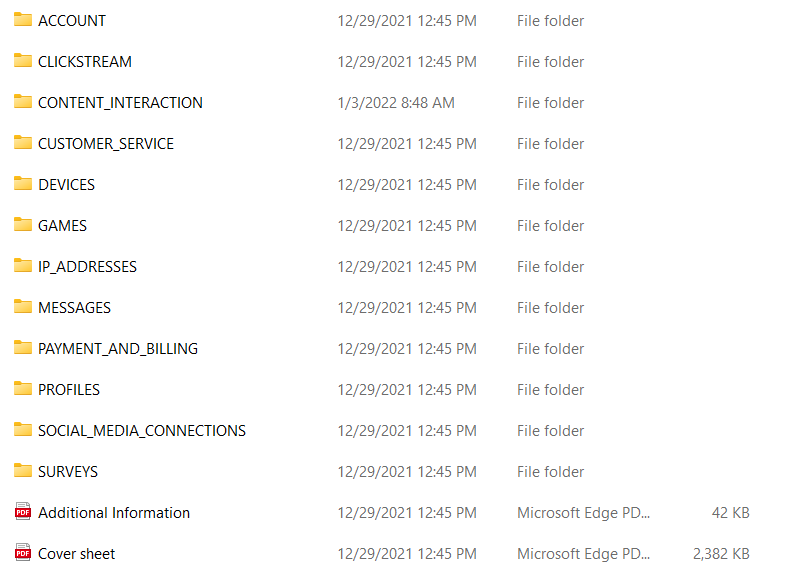

Our goal is to figure out how much time I've spent watching Netflix. Content Interaction seems like the most likely folder to contain that data. If we open it, we'll find a file called `ViewingActivity.csv` that looks exactly like what we want — a log of everything we've viewed over the history of the account.

There's a file called `Cover sheet.pdf` that contains data dictionaries for all of the `.csv` files. This data dictionary can help us answer questions and avoid errors.

## Load the data

Let us start by importing the the most common libraries for basic data analysis and visualization, such as `pandas`, `matplotlib` and `seaborn`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read the Netflix data into a dataframe called `netflix`
netflix = pd.read_csv('ViewingActivity.csv')
netflix.head()

,Profile Name,Start Time,Duration,Attributes,Title,Supplemental Video Type,Device Type,Bookmark,Latest Bookmark,Country
0,Evis,2024-03-04 20:21:53,00:26:08,NaN,The Rookie: Season 2: Follow-Up Day (Episode 13),NaN,Chrome PC (Cadmium),00:42:32,00:42:32,AL (Albania)
1,Evis,2024-03-04 18:32:12,00:16:23,NaN,The Rookie: Season 2: Follow-Up Day (Episode 13),NaN,Chrome PC (Cadmium),00:16:24,Not latest view,AL (Albania)
2,Evis,2024-03-04 18:16:35,00:14:27,NaN,The Rookie: Season 2: Now and Then (Episode 12),NaN,Chrome PC (Cadmium),00:42:31,00:42:31,AL (Albania)
3,Evis,2024-03-04 17:03:49,00:00:05,Autoplayed: user action: None;,Resident Alien: Season 1_hook_04_16x9,HOOK,Chrome PC (Cadmium),00:00:05,00:00:05,AL (Albania)
4,Evis,2024-02-29 14:00:57,00:02:42,NaN,The Rookie: Season 2: Now and Then (Episode 12),NaN,DefaultWidevineAndroidPhone,00:27:06,Not latest view,AL (Albania)


We can extract basic information regarding the data by calling the method `info()`, which allows us to quickly observe that in this case the dataset contains over `6000` records which hold information about key elements for our analysis such as:
- `Start time`, i.e., the starting time of watching a particular episode
- `Duration`, i.e., the length of watching for a particular sessions
- `Title` denoting the full title of the show/movie (e.g., including also season and episode number in case of a show)

and other information, such as `Profile Name`, `Attributes`, `Supplemental Video Type`, `Device Type`,`Bookmark`, `Latest Bookmark`, `Country` which are not relevant for our analysis. For a full decription of the data refer to the `Cover_Sheet` document 

In [6]:
netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6081 entries, 0 to 6080
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Profile Name             6081 non-null   object
 1   Start Time               6081 non-null   object
 2   Duration                 6081 non-null   object
 3   Attributes               1875 non-null   object
 4   Title                    6081 non-null   object
 5   Supplemental Video Type  1270 non-null   object
 6   Device Type              6081 non-null   object
 7   Bookmark                 6081 non-null   object
 8   Latest Bookmark          6081 non-null   object
 9   Country                  6081 non-null   object
dtypes: object(10)
memory usage: 475.2+ KB


## Preparing Data for Analysis
### Dropping Unnecessary Columns
First, we'll start by dropping the columns we're not planning to use. In this case, we're planning to analyze how much and when we watched certain shows, so we'll need to keep the `Start Time`, `Duration`, `Decice Type` and `Title` columns. Everything else can go.

**Disclaimer: deleting data is not a good idea, however for this particular simple project we're only interested in a portion of our data**

In [7]:
netflix = netflix.drop(['Profile Name', 'Attributes', 'Supplemental Video Type', 
                        'Bookmark', 'Latest Bookmark', 'Country'], axis=1)
netflix.head()

,Start Time,Duration,Title,Device Type
0,2024-03-04 20:21:53,00:26:08,The Rookie: Season 2: Follow-Up Day (Episode 13),Chrome PC (Cadmium)
1,2024-03-04 18:32:12,00:16:23,The Rookie: Season 2: Follow-Up Day (Episode 13),Chrome PC (Cadmium)
2,2024-03-04 18:16:35,00:14:27,The Rookie: Season 2: Now and Then (Episode 12),Chrome PC (Cadmium)
3,2024-03-04 17:03:49,00:00:05,Resident Alien: Season 1_hook_04_16x9,Chrome PC (Cadmium)
4,2024-02-29 14:00:57,00:02:42,The Rookie: Season 2: Now and Then (Episode 12),DefaultWidevineAndroidPhone


### Converting Strings to Datetime and Timedelta in Pandas
As we observed when calling the `info()` method, all three columns are stored as of type `object`. That's fine for the `Title` column, but we need to change the two time-related columns into the correct datatypes before we can work with them.

Specifically, we need to do the following:

- Convert `Start Time` to `datetime` (a data and time format pandas can understand and perform calculations with)
- Convert `Start Time` from UTC to our local timezone
- Convert `Duration` to `timedelta` (a time duration format pandas can understand and perform calculations with)

In [8]:
#  We'll also add the optional argument utc=True so that our datetime data has the UTC timezone attached to it. 
# This is important, since we'll need to convert it to a different timezone in the next step.

netflix['Start Time'] = pd.to_datetime(netflix['Start Time'], utc=True)
netflix.dtypes

Start Time     datetime64[ns, UTC]
Duration                    object
Title                       object
Device Type                 object
dtype: object

We can convert datetimes to any timezone using the `.tz_convert()` and passing it an argument with the string for the timezone we want to convert to. In this case, that's `Europe/Tirane`. To find your specific timezone, [here's a handy reference of TZ timezone options.](https://en.wikipedia.org/wiki/List_of_tz_database_time_zones)

The tricky bit here is that we can only use `.tz_convert()` on a `DatetimeIndex`, so we need to set our `Start Time` column as the index using `set_index()` before we perform the conversion.

In this tutorial, we'll then use `reset_index()` to turn it back into a regular column afterwards

Putting all of that together looks like this:

In [9]:
# change the Start Time column into the dataframe's index
netflix = netflix.set_index('Start Time')

# convert from UTC timezone to Tirana time
netflix.index = netflix.index.tz_convert('Europe/Tirane')

# reset the index so that Start Time becomes a column again
netflix = netflix.reset_index()

# double-check that it worked
netflix.head()

,Start Time,Duration,Title,Device Type
0,2024-03-04 21:21:53+01:00,00:26:08,The Rookie: Season 2: Follow-Up Day (Episode 13),Chrome PC (Cadmium)
1,2024-03-04 19:32:12+01:00,00:16:23,The Rookie: Season 2: Follow-Up Day (Episode 13),Chrome PC (Cadmium)
2,2024-03-04 19:16:35+01:00,00:14:27,The Rookie: Season 2: Now and Then (Episode 12),Chrome PC (Cadmium)
3,2024-03-04 18:03:49+01:00,00:00:05,Resident Alien: Season 1_hook_04_16x9,Chrome PC (Cadmium)
4,2024-02-29 15:00:57+01:00,00:02:42,The Rookie: Season 2: Now and Then (Episode 12),DefaultWidevineAndroidPhone


Now, let's deal with our `Duration` column. This is, as the name suggests, a duration — a measure of a length of time. So, rather than converting it to a datetime, we need to convert it to a timedelta, which is a measure of time duration that pandas understands.

In [10]:
netflix['Duration'] = pd.to_timedelta(netflix['Duration'])
print(netflix.dtypes)
netflix.head()


Start Time     datetime64[ns, Europe/Tirane]
Duration                     timedelta64[ns]
Title                                 object
Device Type                           object
dtype: object


,Start Time,Duration,Title,Device Type
0,2024-03-04 21:21:53+01:00,0 days 00:26:08,The Rookie: Season 2: Follow-Up Day (Episode 13),Chrome PC (Cadmium)
1,2024-03-04 19:32:12+01:00,0 days 00:16:23,The Rookie: Season 2: Follow-Up Day (Episode 13),Chrome PC (Cadmium)
2,2024-03-04 19:16:35+01:00,0 days 00:14:27,The Rookie: Season 2: Now and Then (Episode 12),Chrome PC (Cadmium)
3,2024-03-04 18:03:49+01:00,0 days 00:00:05,Resident Alien: Season 1_hook_04_16x9,Chrome PC (Cadmium)
4,2024-02-29 15:00:57+01:00,0 days 00:02:42,The Rookie: Season 2: Now and Then (Episode 12),DefaultWidevineAndroidPhone


## Analyzing Netflix Data

### How much Netflix have I watched? 
To provide a relevant context for this question, we can observe the date of the first and the last session watched. Then, we  determine the overall timeframe, and approximate this duration in months by dividing the total number of days by 30.

In [11]:
# the earliest time 
netflix['Start Time'].min()
# the latest time 
netflix['Start Time'].max()
# timeframe
timeframe = netflix['Start Time'].max() - netflix['Start Time'].min()

total_days = timeframe.days
print("Timeframe in days:", total_days)

total_months = total_days / 30
print("Approximate timeframe in months:", total_months)

Timeframe in days: 1410
Approximate timeframe in months: 47.0


We can also calculate the total watch time from the `Duration` column. It sums up all the durations and extracts the total number of days from the resulting timedelta object, providing the overall watch time in days.

In [12]:
# total watch time
total_watch_time = netflix['Duration'].sum()
total_watch_time_days = total_watch_time.days
print(total_watch_time_days)

69


For a period of approximately 47 months, I have watched overall almost 69 days of Netflix. **Before judging make sure to do the analysis on your own data first :)**

![info](https://media.giphy.com/media/MuJDYvbYKzMwONKvdO/giphy.gif)

To be more accurate, we can calculate how much time, on average, I spend each day watching Netflix

In [13]:
hours_in_day = 24
minutes_in_hour = 60
avg_watch_time_per_day = total_watch_time / timeframe * hours_in_day * minutes_in_hour
print(f"Average watch time per day {avg_watch_time_per_day:.2f} minutes")

Average watch time per day 70.58 minutes


Well, **70 minutes per day, on average**. It's not bad considering that it's a shared account :)

## Most Viewed Shows

Let's find out which Netflix shows take the most screen time?

First, we group the shows and add up how long we've watched each one. Then, we pick out the top 5 champions that have kept me glued to screen the longest.


In [14]:
# Aggregate the data by 'Title' and sum up the total duration for each show
top_shows = netflix.groupby('Title')['Duration'].sum().sort_values(ascending=False)

# Get the top 5 shows
top_5_shows = top_shows.head(5)

print("Top 5 shows watched the longest:")
print(top_5_shows)


Top 5 shows watched the longest:
Title
We Can Be Heroes                    0 days 09:06:06
Super Monsters Furever Friends      0 days 05:12:31
Matilda                             0 days 05:10:06
Glass Onion: A Knives Out Mystery   0 days 04:23:02
Enola Holmes                        0 days 03:55:07
Name: Duration, dtype: timedelta64[ns]


Oops! It looks like our first try might not give us the best results. 

That's because tv shows have lots of episodes with different titles. 

Time for a clever trick using something called regex! We'll use it to focus only on the main title of each show, ignoring those sneaky episode numbers. Then, we'll group everything by these clean titles and see which ones we've watched the most. 


Finally, we'll reveal the top 5 shows that have really eaten up our watch time!

In [15]:
# Extract the main title of the show (excluding episode numbers)
netflix['Main Title'] = netflix['Title'].str.extract(r'(^.*?):')

# Group by the main title and sum up the total duration for each show
top_shows_grouped = netflix.groupby('Main Title')['Duration'].sum().sort_values(ascending=False)

# Get the top 5 shows
top_5_shows_grouped = top_shows_grouped.head(5)

print("Top 5 shows watched the longest (grouped by series):")
print(top_5_shows_grouped)


Top 5 shows watched the longest (grouped by series):
Main Title
The Blacklist        6 days 08:46:49
Suits                3 days 04:43:14
Miraculous           2 days 06:59:43
Brooklyn Nine-Nine   2 days 02:40:34
Modern Family        1 days 20:35:38
Name: Duration, dtype: timedelta64[ns]


Now we're talking. Top of the list is **The Blacklist**. Isn't it ironic?

Let's visualize these data. First, we convert the duration of each viewing session into hours. Then, we group the data by the main title of each show and sum up the total duration watched for each show. 

Afterward, we pick out the top 5 shows with the longest total watch times. Finally, we create a bar plot to visualize these top 5 shows, showing how much time we've spent watching each series.



![blacklist](https://media.giphy.com/media/fVVzjLZCupAOV6oUdi/giphy.gif)



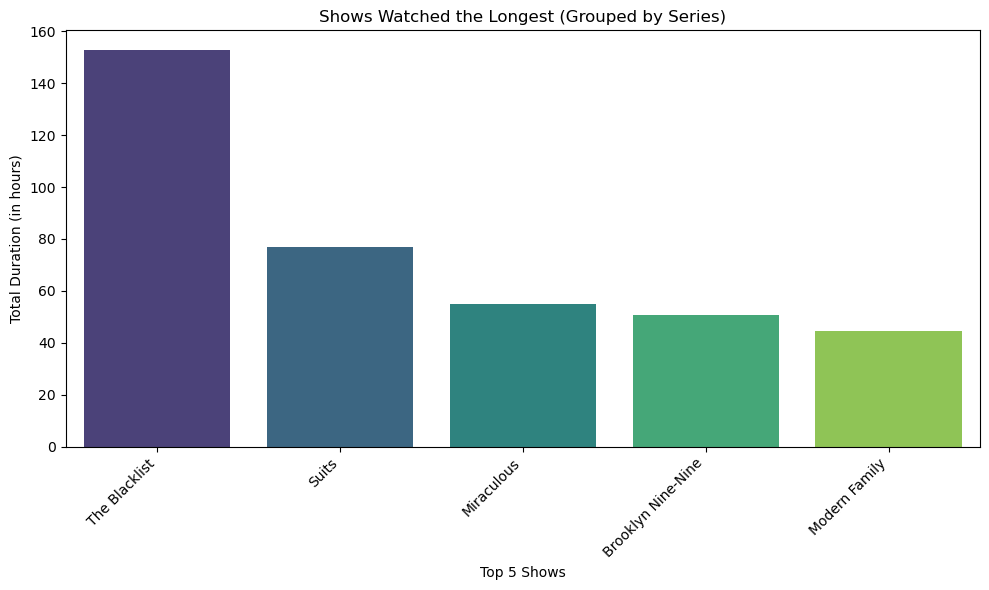

In [16]:
# Convert 'Duration' to hours for plotting
netflix['Duration_hours'] = netflix['Duration'].dt.total_seconds() / 3600

# Group by the main title and sum up the total duration for each show
top_shows_grouped = netflix.groupby('Main Title')['Duration_hours'].sum().sort_values(ascending=False)

# Get the top 5 shows
top_5_shows_grouped = top_shows_grouped.head(5)

# Plot the top 5 shows watched the longest
plt.figure(figsize=(10, 6))
sns.barplot(x=top_5_shows_grouped.index, y=top_5_shows_grouped.values, palette="viridis")
plt.title("Shows Watched the Longest (Grouped by Series)")
plt.xlabel("Top 5 Shows")
plt.ylabel("Total Duration (in hours)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Netflix Sessions by Day of the Week

Let us now analyze and visualize the distribution of Netflix viewing sessions across different days of the week.

Key steps to achieve this goal:

- Extract the day of the week and hour of the day from the 'Start Time' column of the Netflix dataset.
- Map the numerical representation of the day of the week to actual day names for better readability.
- Count the number of occurrences for each day of the week.
- Plot a bar graph to visualize the number of Netflix sessions for each day of the week, ensuring proper ordering and labeling for clarity.

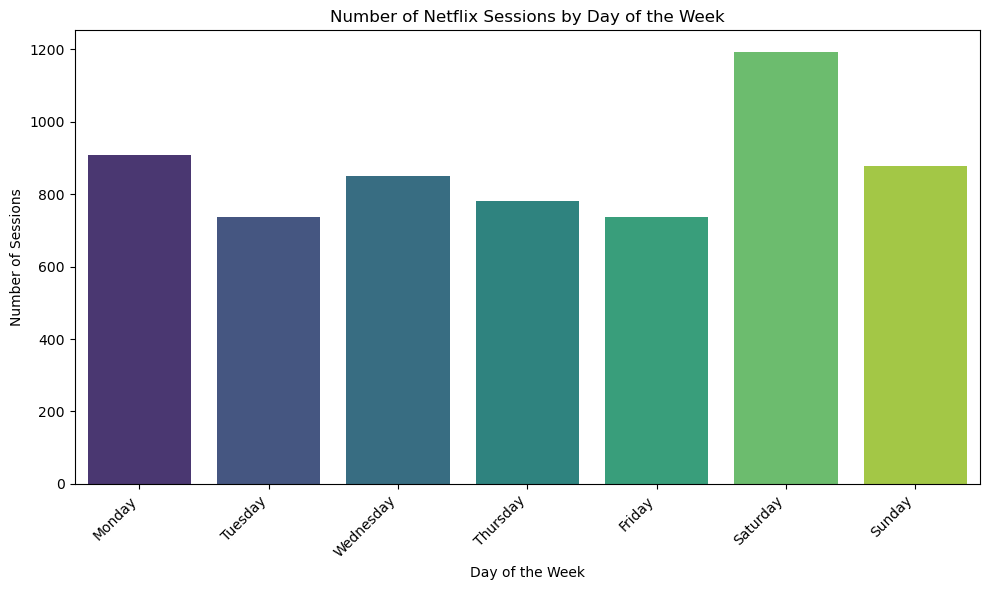

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Extract the day of the week and hour of the day from the 'Start Time'
netflix['Day_of_week'] = netflix['Start Time'].dt.dayofweek

# Map numerical day of the week to actual day names
day_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
netflix['Day_of_week'] = netflix['Day_of_week'].map(day_map)

# Count the number of occurrences for each day of the week
day_of_week_counts = netflix['Day_of_week'].value_counts().sort_index()

# Plotting for the days of the week
plt.figure(figsize=(10, 6))

sns.barplot(
    x=day_of_week_counts.index, 
    y=day_of_week_counts.values, 
    order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette="viridis")

plt.title("Number of Netflix Sessions by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Netlix Sessions by Hour of Day

What if we want to analyze and visualize the distribution of total Netflix viewing duration across different hours of the day.

Similarly, key steps include:


- Extract the hour of the day from the 'Start Time' column of the Netflix dataset.
- Group the data by the hour of the day and calculate the total duration watched for each hour.
- Sort the results by the hour of the day.
- Plot a bar graph to visualize the total Netflix duration for each hour of the day, ensuring proper labeling and formatting for clarity.

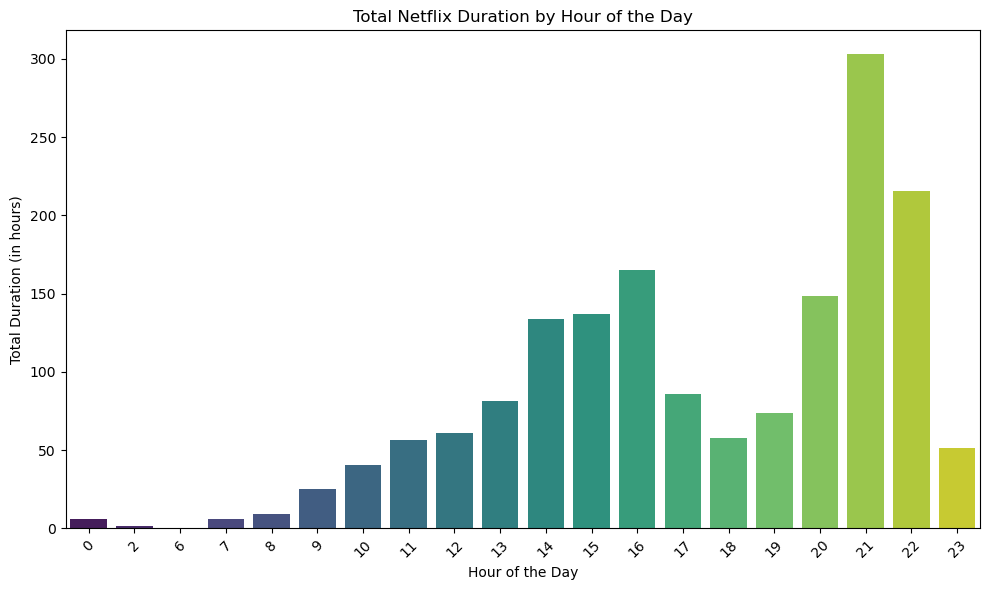

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

netflix['Month'] = netflix['Start Time'].dt.month
# Extract the hour of the day from the 'Start Time' column
netflix['Hour_of_day'] = netflix['Start Time'].dt.hour

# Group by the hour of the day and sum up the total duration for each hour
hour_of_day_duration = netflix.groupby('Hour_of_day')['Duration_hours'].sum().sort_index()

# Plotting for the hours of the day
plt.figure(figsize=(10, 6))
sns.barplot(x=hour_of_day_duration.index, y=hour_of_day_duration.values, palette="viridis")
plt.title("Total Netflix Duration by Hour of the Day")
plt.xlabel("Hour of the Day")
plt.ylabel("Total Duration (in hours)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Netflix Trends over Months

I am now interested to understand if my Netlix viewing habits are linear or if they change over months. 

Key steps to achieve this goal:

- Extract the month from the 'Start Time' column of the Netflix dataset.
- Count the number of viewing sessions for each month.
- Sort the monthly viewing hours counts by month.
- Plot a line graph to visualize the trends in Netflix viewing sessions over the months, ensuring proper labeling and formatting for clarity. The x-axis represents the months, while the y-axis represents the number of viewing sessions.

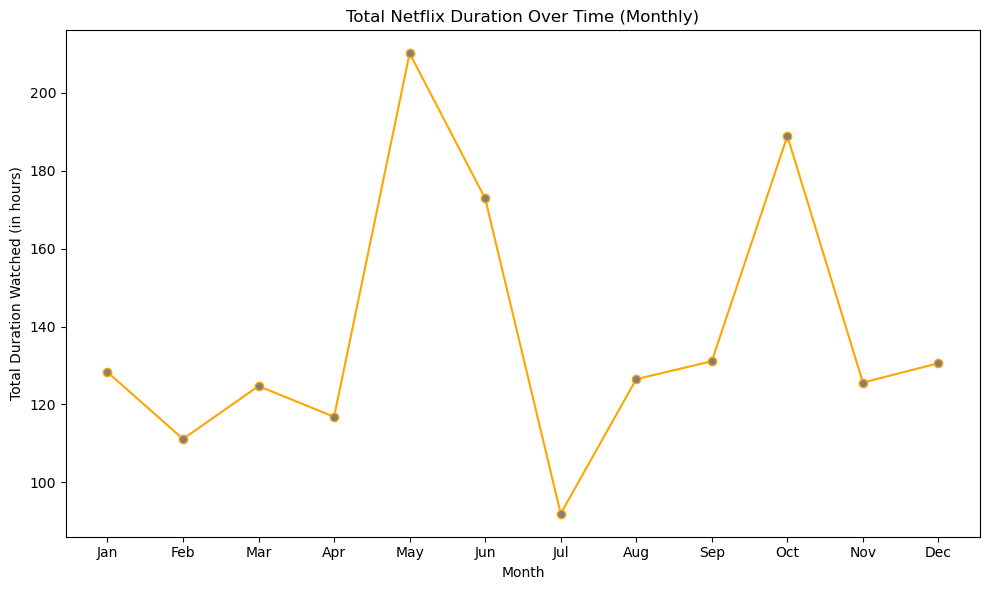

In [19]:
# Aggregate the data by month and sum up the total duration for each month
monthly_duration = netflix.groupby('Month')['Duration_hours'].sum()

# Plotting viewing trends over time using a line plot
plt.figure(figsize=(10, 6))
monthly_duration.plot(
    kind='line', 
    marker='o', 
    color='orange', 
    markerfacecolor='gray'
)
plt.title("Total Netflix Duration Over Time (Monthly)")
plt.xlabel("Month")
plt.ylabel("Total Duration Watched (in hours)")
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.tight_layout()

plt.show()


We can visualize Netflix viewing trends over time by creating a heatmap. 


We first aggregate the viewing data by month and hour of the day, calculating the total duration watched for each combination. 

Then, we plot this data using a heatmap, where each cell represents the total hours watched during a specific hour of the day in a particular month. 


The intensity of the color indicates the level of viewing activity, providing insights into when users are most active on Netflix.

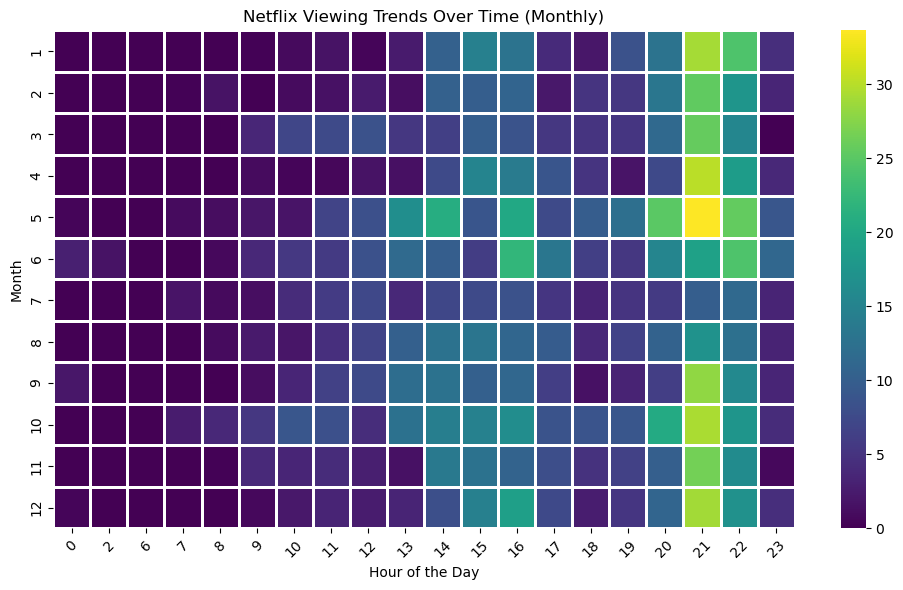

In [20]:
# Aggregate the data by month and hour of the day and sum up the total duration for each combination
pivot_monthly_viewing = netflix.groupby(['Month', 'Hour_of_day'])['Duration_hours'].sum().unstack(fill_value=0)

# Plotting viewing trends over time using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_monthly_viewing, cmap="viridis", linecolor='white', linewidths=1)
plt.title("Netflix Viewing Trends Over Time (Monthly)")
plt.xlabel("Hour of the Day")
plt.ylabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Concluding remarks

In this project, we dug into my Netflix activity data to uncover some interesting insights. We found out how much time I spent watching Netflix, which shows I watched the most, and when I tended to watch the most. By looking at patterns over months, we even saw how my viewing habits changed over time. But amidst all the data, one thing's clear: no matter how much I watch, there's always another episode waiting. 

![work_day](https://media.giphy.com/media/XymXANrzgI4k6FL6zr/giphy.gif)

You can give it a try with your own data and further expand this simple analysis in any way you like. 